<a href="https://colab.research.google.com/github/MiguelPastorB/pastorbeltra/blob/main/Bernoulli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1: Problema de los k-brazos
- **Alumno:** Pastor Beltrá, Miguel
- **Asignatura:** Extensiones de Machine Learning
- **Curso:** 2025/2026
- **Grupo:** pastorbeltra

**Índice**   
1. [Introducción](#introduccion)
2. [Desarrollo](#desarrollo)
3. [Algoritmos](#algoritmos)
4. [Evaluación](#evaluacion)
5. [Conclusiones](#conclusiones)
6. [Uso de la IA generativa](#ia-generativa)
7. [Bibliografía y referencias](#referencias)

# 1. Introducción <a name="introduccion"></a>

En esta práctica implementamos y comparamos los algoritmos $\epsilon$-greedy, $\epsilon$-decaimiento, UCB1 y Softmax para abordar el dilema de exploración-explotación en un entorno de recompensas Bernoulli. En este caso, cada acción produce una recompensa binaria (éxito o fracaso), lo que permite modelar escenarios donde solo importa si se obtiene o no un resultado positivo.

El objetivo es analizar el comportamiento de los algoritmos mediante las gráficas de recompensa promedio, arrepentimiento acumulado y porcentaje de selección óptima, evaluando su rendimiento en este contexto discreto y estocástico.

# 2. Desarrollo <a name="desarrollo"></a>

Hemos realizado esta práctica en un entorno local utilizando Visual Studio Code. Sin embargo, como especificación del enunciado, el proyecto también está preparado para ejecutarse en Google Colab sin necesidad de configuración adicional. En esta sección tambien incluimos todos los imports necesarios para el correcto funcionamiento del notebook.

## 2.1. Entorno Colab y VSCode

A continuación, incluimos algunas celdas auxiliares para adaptar el entorno de ejecución en Colab, permitiendo acceder correctamente al repositorio y a los módulos del proyecto.

In [38]:
#!rm -r pastorbeltra/
#!git clone https://github.com/MiguelPastorB/pastorbeltra.git
#!cd pastorbeltra/

Esta celda de código añade la carpeta src al path de Python, lo que permite importar correctamente los módulos del proyecto sin necesidad de instalar el paquete.

In [39]:
import sys
import os

# Añadimos la carpeta 'src' al path de búsqueda de Python
sys.path.append(os.path.abspath('src'))

## 2.2. Importaciones y semilla

Importamos todas las dependencias necesarias para la ejecución de los experimentos, incluidos los distintos componentes implementados en el proyecto: los algoritmos de aprendizaje ($\epsilon$-greedy, UCB1 y Softmax), las clases que definen los brazos (*arms*) y el entorno *bandit*, así como las funciones de visualización utilizadas para analizar los resultados (recompensa promedio, arrepentimiento y porcentaje de selección óptima).

Finalmente, fijamos una semilla aleatoria (`seed = 2024`) tanto en NumPy como en la librería `random`. Esto garantiza la **reproducibilidad** de los experimentos, permitiendo obtener los mismos resultados en distintas ejecuciones.


In [40]:
# Importamos las librerías necesarias
import numpy as np
import random

# Importamos nuestros algoritmos, brazos y funciones de visualización
from src.algorithms.algorithm import Algorithm
from src.algorithms.epsilon_greedy import EpsilonGreedy, DecayingEpsilonGreedy
from src.algorithms.ucb1 import UCB1
from src.algorithms.softmax import Softmax
from src.arms.arm import Arm
from src.arms.armnormal import ArmNormal
from src.arms.bandit import Bandit
from src.arms.armbinomial import ArmBinomial
from src.plotting.plotting import plot_average_rewards, plot_optimal_selections, plot_regret

# Establecemos una semilla para reproducibilidad
seed = 2024
np.random.seed(seed)
random.seed(seed)

# 3. Algoritmos <a name="algoritmos"></a>

`run_experiment` simula la interacción de los algoritmos con un bandido k-brazos Bernoulli, donde cada brazo devuelve una recompensa binaria (0 o 1) con cierta probabilidad.

Para cada algoritmo y paso temporal:

* Seleccionamos un brazo.
* Recibimos la recompensa del entorno (0 o 1).
* Actualizamos las estimaciones del algoritmo.
* Registramos las métricas: recompensa promedio, % de selección óptima y arrepentimiento acumulado.

Promediamos los resultados sobre todas las ejecuciones para obtener curvas más estables y comparables entre algoritmos.

In [41]:
def run_experiment(algorithms, n_arms, n_steps, n_runs):
    # Matrices para almacenar resultados
    all_rewards = np.zeros((len(algorithms), n_steps))
    optimal_counts = np.zeros((len(algorithms), n_steps))
    regret_accumulated = np.zeros((len(algorithms), n_steps))

    # Definimos las probabilidades reales de los brazos
    probs = np.linspace(0.1, 0.9, n_arms) 
    optimal_arm_idx = np.argmax(probs)
    max_mu = probs[optimal_arm_idx]

    for run in range(n_runs):
        # Reiniciamos brazos para cada run y usamos ArmBinomial con n=1 para simular Bernoulli
        arms = [ArmBinomial(n=1, p=p) for p in probs]
        bandit = Bandit(arms)
        
        # Reiniciamos algoritmos para garantizar independencia
        for alg in algorithms:
            alg.reset() 

        for step in range(n_steps):
            for i, alg in enumerate(algorithms):
                # El agente elige brazo
                arm_idx = alg.select_arm()
                
                # El entorno devuelve recompensa
                reward = bandit.pull_arm(arm_idx)
                
                # El agente aprende actualizando sus estimaciones
                alg.update(arm_idx, reward)
                
                # Guardamos métricas
                all_rewards[i, step] += reward
                if arm_idx == optimal_arm_idx:
                    optimal_counts[i, step] += 1
                
                # Calculamos regret instantáneo
                current_regret = max_mu - probs[arm_idx]
                regret_accumulated[i, step] += current_regret

    # Promediamos resultados por el número de runs para suavizar curvas
    avg_rewards = all_rewards / n_runs
    avg_optimal = (optimal_counts / n_runs) * 100 # En porcentaje
    avg_regret = np.cumsum(regret_accumulated / n_runs, axis=1) # Acumulado temporalmente

    # Ahora devolvemos las tres métricas
    return avg_rewards, avg_optimal, avg_regret

# 4. Evaluación <a name="evaluacion"></a>

En esta sección ejecutamos los experimentos para analizar y comparar el desempeño de los distintos algoritmos en el entorno de bandido k-brazos. Estudiaremos tanto el comportamiento general de varios algoritmos como la variación de valores de $\epsilon$ en $\epsilon$-greedy.

## 4.1. Evaluación valores de $\epsilon$

En esta parte estudiamos cómo el parámetro $\epsilon$ influye en el desempeño del algoritmo Epsilon-Greedy. Definimos varios valores de $\epsilon$ = (0.0, 0.01, 0.1, 0.5) y ejecutamos el experimento para cada uno, manteniendo constantes los demás parámetros.

Este análisis permite observar cómo el grado de exploración afecta la recompensa promedio, la selección del brazo óptimo y el arrepentimiento acumulado, mostrando de manera intuitiva la importancia de elegir un $\epsilon$ adecuado.

Definimos los parámetros del experimento:

* **n_arms = 10:** número de brazos disponibles.
* **n_steps = 1000:** pasos de interacción por ejecución.
* **n_runs = 2000:** ejecuciones independientes para promediar resultados y obtener curvas estables.

In [42]:
# Parámetros del experimento
n_arms = 10
n_steps = 1000
n_runs = 2000

# Definimos varios Epsilon-Greedy con distintos valores
epsilon_values = [0.0, 0.01, 0.1, 0.5]
eps_algorithms = [EpsilonGreedy(k=n_arms, epsilon=e) for e in epsilon_values]

# Ejecutamos
avg_rewards, opt_selections, regret_data = run_experiment(eps_algorithms, n_arms, n_steps, n_runs)

En esta comparativa, hemos identificado con claridad las tres fases del aprendizaje. El valor $\epsilon = 0.5$ es el más veloz inicialmente, ya que su agresiva exploración le permite descubrir el brazo óptimo antes que nadie. Sin embargo, su precisión se estanca rápidamente en un 55% debido a que sigue eligiendo al azar la mitad del tiempo. Por el contrario, el valor $\epsilon = 0.01$ muestra un crecimiento lento pero constante, sugiriendo que a muy largo plazo podría ser el más preciso. Nuestro ganador, $\epsilon = 0.1$, logra el mejor equilibrio, estabilizándose por encima del 80% y demostrando ser la configuración más robusta para este horizonte temporal. En cuanto a $\epsilon = 0.0$, se mantiene en el 0% de éxito, confirmando que sin exploración el agente queda atrapado en su primera elección, generalmente incorrecta.

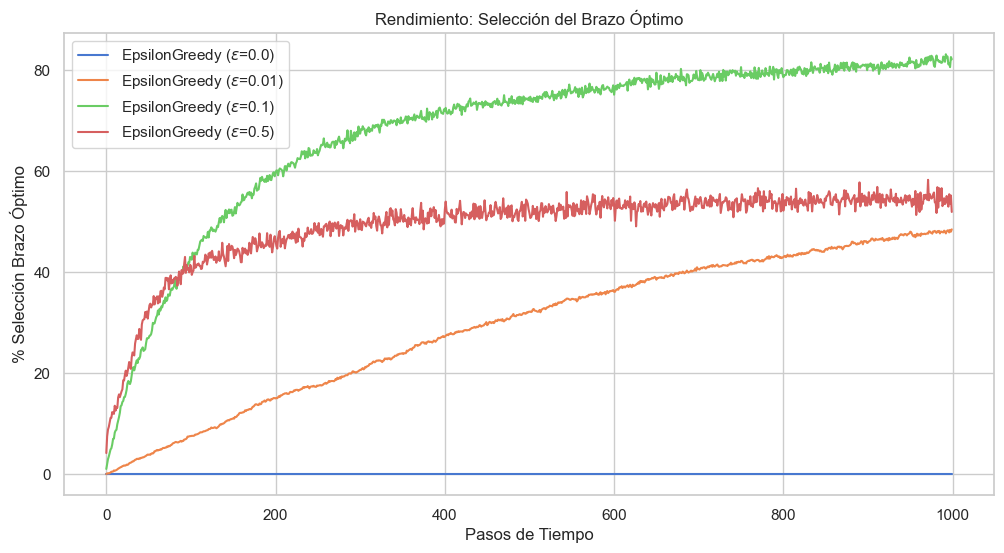

In [43]:
# Gráfica 1: % de Selección del Brazo Óptimo
plot_optimal_selections(n_steps, opt_selections, eps_algorithms)

El gráfico de Regret nos revela el "coste de la ignorancia" frente al "coste de la exploración excesiva". Hemos observado que la curva de $\epsilon = 0.1$ es la que presenta la menor pendiente, lo que indica una eficiencia superior. La curva de $\epsilon = 0.5$, aunque encuentra el brazo óptimo rápido, su Regret sigue creciendo de forma lineal y pronunciada porque el agente, aun sabiendo cuál es el mejor brazo, decide no elegirlo el 50% de las veces para seguir explorando innecesariamente. Finalmente, el $\epsilon = 0.0$ dispara su Regret hasta los 800 puntos, demostrando que ser codicioso es la estrategia más costosa en entornos con incertidumbre.

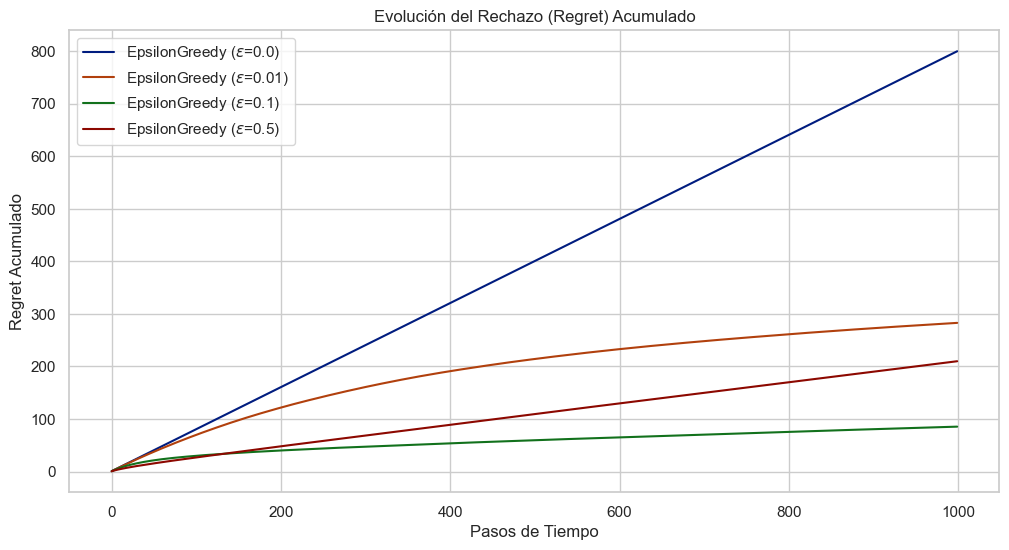

In [44]:
# Gráfica 2: Regret Acumulado
plot_regret(n_steps, regret_data, eps_algorithms)

En cuanto a la recompensa promedio, el valor $\epsilon = 0.1$ lidera la tabla con una recompensa media superior a $0.8$. Observamos que $\epsilon = 0.5$ alcanza un límite de recompensa muy pronto ($0.7$ aprox.) pero es incapaz de superarlo. La curva de $\epsilon = 0.01$ es la más prometedora por su tendencia, dado que al final del experimento ya está superando al valor de $0.5$, lo que nos permite concluir que para experimentos de larga duración, valores de $\epsilon$ más pequeños son preferibles.

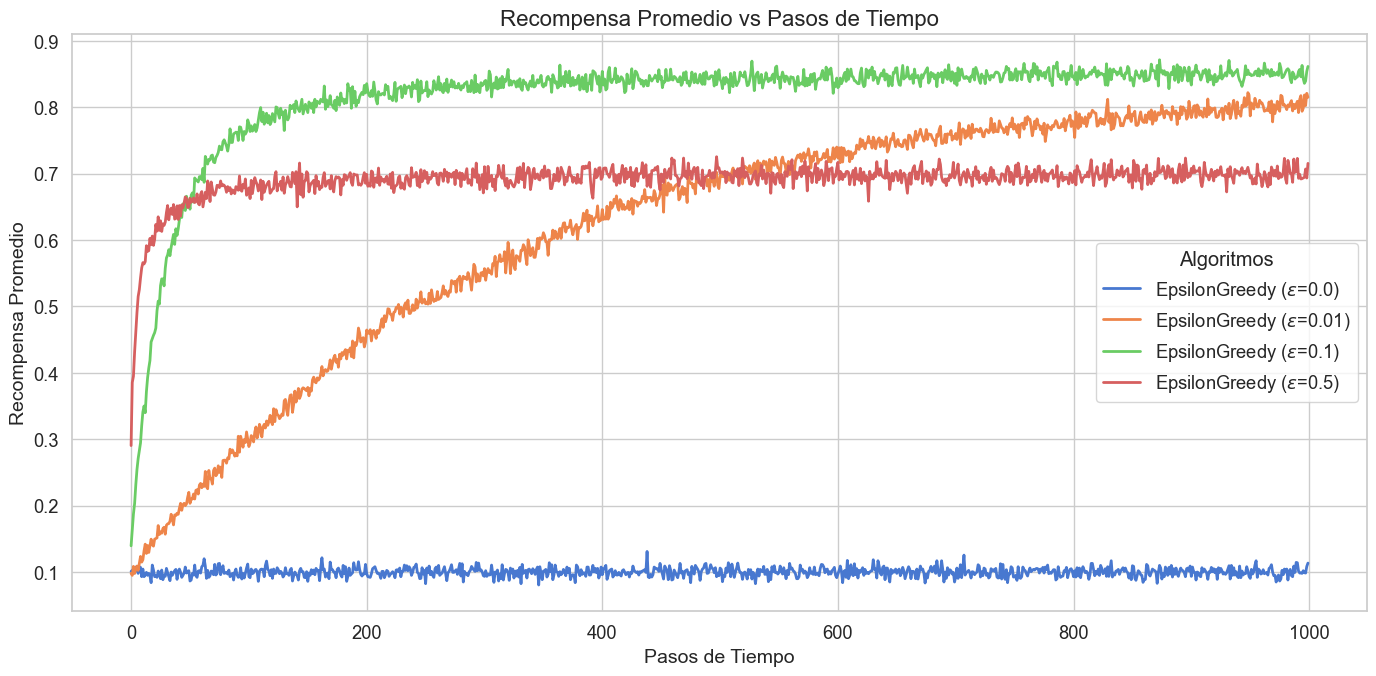

In [45]:
# Gráfica 3: Recompensa Promedio
plot_average_rewards(n_steps, avg_rewards, eps_algorithms)

# 4.2. Evaluación general

Una vez obtenido el valor $\epsilon = 0.1$ como nuestro mejor resultado para emplear en nuestra práctica, procedemos al análisis general del bandido k-brazos en la distribución Bernoulli.

Primero, definimos los parámetros del experimento:

* **n_arms = 10:** número de brazos disponibles.
* **n_steps = 1000:** pasos de interacción por ejecución.
* **n_runs = 2000:** ejecuciones independientes para promediar resultados y obtener curvas estables.

Luego, instanciamos los algoritmos a comparar:

* **$\epsilon$-greedy:** con $\epsilon = 0.1$.
* **$\epsilon$-decaimiento:** una variante que reduce $\epsilon$ a lo largo del tiempo para favorecer la explotación.
* **UCB1:** equilibra exploración y explotación según la incertidumbre.
* **Softmax:** selecciona brazos de manera probabilística según sus estimaciones y una temperatura (temperature = 0.1).

In [46]:
# Parámetros del experimento
n_arms = 10
n_steps = 1000
n_runs = 2000

# Lista de algoritmos a comparar
all_algorithms = [
    EpsilonGreedy(k=n_arms, epsilon=0.1),
    DecayingEpsilonGreedy(k=n_arms),
    UCB1(k=n_arms),
    Softmax(k=n_arms, temperature=0.1)
]

# Ejecutamos
avg_rewards, opt_selections, regret_data = run_experiment(all_algorithms, n_arms, n_steps, n_runs)

En esta gráfica, observamos que el algoritmo $\epsilon$-greedy ($\epsilon=0.1$) es el más eficiente a corto plazo, estabilizándose en un valor cercano al 80%. Este límite es coherente con su configuración, ya que el 10% de exploración forzada le impide alcanzar el 100% de precisión. Por otro lado, UCB1 muestra una fase inicial de alta inestabilidad debido a su necesidad de explorar todos los brazos antes de confiar en sus estimaciones, mientras que la versión con $\epsilon$-decaimiento se mantiene en un 0%, lo que nos indica que el ritmo de reducción de $\epsilon$ es demasiado lento para el horizonte de 1000 pasos definido.

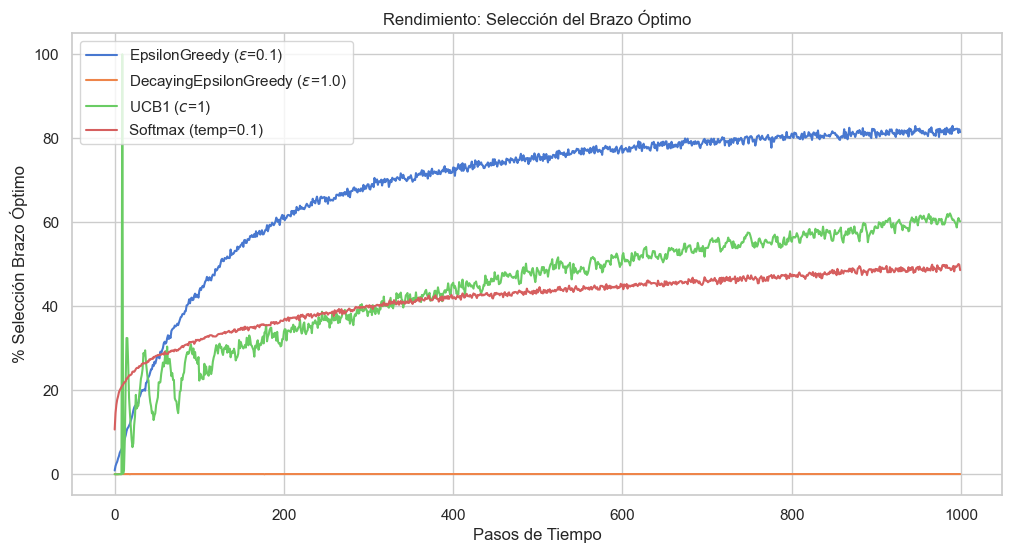

In [47]:
# Gráfica 1: % de Selección del Brazo Óptimo
plot_optimal_selections(n_steps, opt_selections, all_algorithms)

Al analizar el Regret, hemos identificado una diferencia significativa en la eficiencia de los agentes. El $\epsilon$-greedy y el Softmax presentan las pendientes más bajas, lo que significa que pierden menos recompensa potencial al tomar decisiones acertadas rápidamente. Al contrario, el $\epsilon$-decaimiento muestra un crecimiento lineal con una pendiente máxima (alrededor de 800 puntos de pérdida acumulada), esto nos confirma que el algoritmo está actuando de forma casi aleatoria, acumulando error en cada paso sin lograr explotar el conocimiento adquirido.

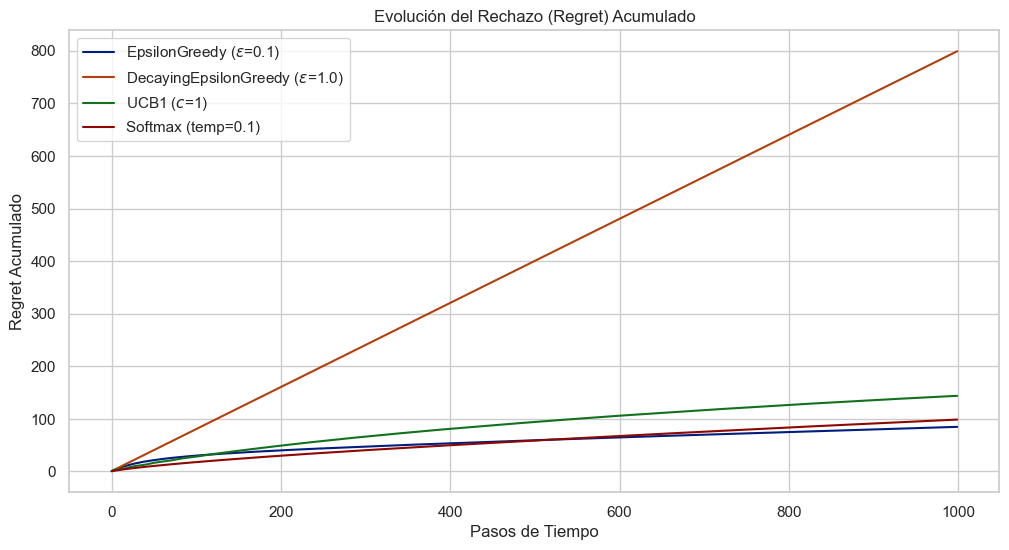

In [48]:
# Gráfica 2: Regret Acumulado
plot_regret(n_steps, regret_data, all_algorithms)

En cuanto a las recompensas promedio, hemos obtenido que el $\epsilon$-greedy lidera la gráfica alcanzando una recompensa media de aproximadamente $0.85$. UCB1 presenta un inicio muy ruidoso con fluctuaciones agresivas, pero hemos notado que a partir del paso 600 su recompensa se estabiliza y comienza a competir con los métodos codiciosos. Finalmente, la recompensa del método con $\epsilon$-decaimiento se estanca en $0.1$, que es el valor esperado de una selección puramente aleatoria en nuestro entorno, reforzando la idea de que este agente no ha salido de su fase de exploración inicial.

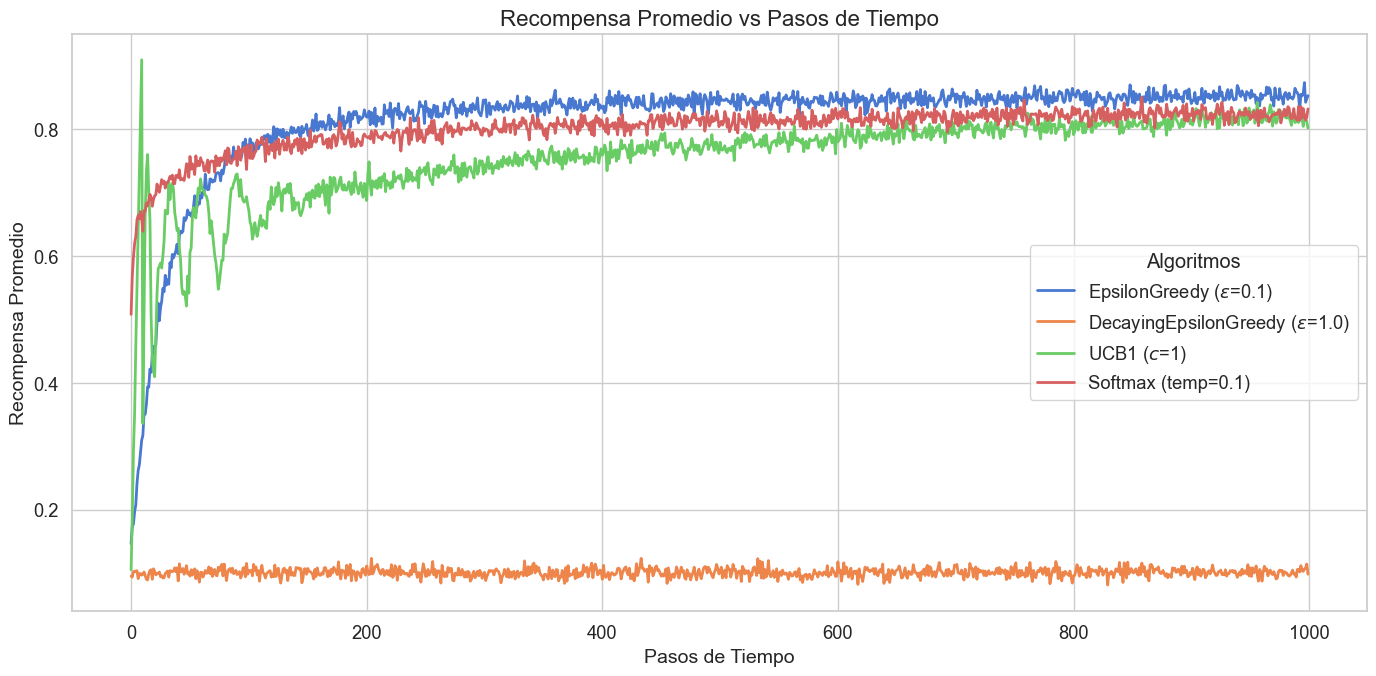

In [49]:
# Gráfica 3: Recompensa Promedio
plot_average_rewards(n_steps, avg_rewards, all_algorithms)

# 5. Conclusiones <a name="conclusiones"></a>

## 5.1. Conclusiones valores de $\epsilon$

Tras analizar los resultados, concluimos lo siguiente:

* **Estrategia sobre-explotación ($\epsilon=0.0$):** en el aprendizaje por refuerzo, la explotación pura es igual a estancamiento. Sin una mínima probabilidad de exploración, el agente no puede corregir una mala estimación inicial, lo que conocemos como quedarse atrapado en un óptimo local.

* **Estrategia sobre-exploración:** una exploración muy alta ($\epsilon=0.5$) es útil para una identificación rápido del entorno, pero penaliza mucho el rendimiento final. En términos de negocio, es como un buscador que dedica la mitad de sus recursos a probar opciones nuevas en lugar de mostrar los resultados que ya sabe que funcionan.

* **Nº de pasos de tiempo:** nuestro análisis nos da a entender que la elección del "mejor $\epsilon$" depende totalmente de cuántos pasos de tiempo tengamos. Si el experimento durase un millón de pasos, $\epsilon = 0.01$ sería probablemente el ganador absoluto, ya que minimiza el desperdicio de pasos una vez que el conocimiento es casi perfecto.

* **Regla del 10%:** validamos mediante los experimentos por qué $\epsilon=0.1$ es el estándar en este tipo de problemas. En la mayoría de los problemas de bandidos con 10 brazos, explora lo suficiente para no perder el óptimo y explota lo suficiente para obtener los beneficios rápidamente.

## 5.2. Conclusiones generales

Tras analizar los resultados, concluimos lo siguiente:

* **$\epsilon$-greedy:** en problemas de bandidos de tipo Bernoulli, donde la recompensa es binaria y las probabilidades no cambian, un valor de $\epsilon=0.1$ ofrece un equilibrio excelente. Su velocidad de convergencia supera a métodos más complejos como UCB1 en horizontes temporales cortos.

* **$\epsilon$-decaimiento:** hemos comprobado que su eficacia es muy dependiente del ajuste del factor de decaimiento ($\alpha$) y del horizonte temporal del experimento. Con nuestra configuración ($\alpha=0.01$), el algoritmo mantuvo una tasa de exploración demasiado elevada durante los 1000 pasos, lo que le impidió transicionar a la fase de explotación. Concluimos que, aunque es el método teóricamente más prometedor al tender a una política codiciosa, requiere una sintonización muy precisa o un número de pasos significativamente mayor para superar a las versiones de $\epsilon$ fijo.

* **UCB1:** aunque UCB1 es más ruidoso al principio, tiene una gran capacidad de autocorrección. Al utilizar intervalos de confianza, el algoritmo se asegura de no ignorar ningún brazo por una mala racha inicial de ceros. Es previsible que, en un experimento de 10,000 pasos, UCB1 acabaría superando al $\epsilon$-greedy fijo, ya que su exploración tiende a cero conforme aumenta la certeza.

* **Softmax:** hemos observado que este método destaca por una mejor exploración, ya que no elige brazos al azar, sino en función de su potencial de recompensa (distribución de Boltzmann). Al utilizar una temperatura baja ($\tau=0.1$), nuestro agente logró estabilizarse rápidamente con un Regret muy bajo, evitando perder pasos en los peores brazos. Sin embargo, hemos observado que puede volverse muy conservador, lo que limita su capacidad para alcanzar el 100% de selección óptima si la temperatura no permite distinguir con suficiente agresividad entre el mejor brazo y sus competidores más cercanos.

# 6. Uso de la IA generativa <a name="ia-generativa"></a>

### Prompt 1. ¿Cómo puedo evitar que el algoritmo epsilon-decaimiento sea menos agresivo para mis 1000 pasos?
Para que el epsilon-decay sea menos agresivo en tus 1000 pasos, puedes reducir la tasa de decaimiento (decay) para que epsilon disminuya más lentamente, aumentar el valor mínimo de epsilon (epsilon_min) para mantener siempre algo de exploración, calcular un decay específico que lleve a epsilon al valor deseado justo al final de los 1000 pasos, o usar un decaimiento lineal en lugar de exponencial, restando una cantidad fija por paso para tener un control más directo sobre la exploración a lo largo del entrenamiento.

# 7. Bibliografía y referencias <a name="referencias"></a>

* Profesor/a [Hernández Molinero], [LD]. (2026). Material de aula virtual y clases de Extensiones de Machine Learning [Material de curso]. Universidad [Nombre de tu universidad].
* A. Maroti, “Reward Based Epsilon Decay,” GitHub Pages, [En línea]. Disponible en: https://aakash94.github.io/Reward-Based-Epsilon-Decay/